
<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_07_abc_modelo_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 7: ABC del aprendizaje de máquina 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

## 1. Entendimiento de los datos

El primer paso consiste en comprender el origen y la naturaleza de los datos. Es fundamental identificar la fuente (por ejemplo, si provienen de un censo, sensores o registros operacionales), así como la unidad de observación, es decir, qué representa cada fila: una persona, un distrito, una vivienda, entre otros. 

También es importante reconocer el tipo de variables presentes en el conjunto de datos, distinguiendo entre variables numéricas, categóricas, espaciales o temporales. En esencia, la pregunta clave en esta etapa es: ¿qué representa físicamente cada observación?


## 2. Calidad de datos (Data Quality)

Una vez entendido el dataset, se debe evaluar su calidad. Esto implica analizar la presencia de valores faltantes y determinar si su ausencia es aleatoria o responde a algún patrón estructural. Asimismo, es necesario examinar los valores atípicos (outliers), diferenciando entre posibles errores de medición y fenómenos reales del sistema.

Adicionalmente, se debe verificar la consistencia de los datos, asegurando que las unidades sean correctas y que los valores se encuentren dentro de rangos razonables.


## 3. Análisis exploratorio (EDA)

El análisis exploratorio permite obtener una primera comprensión de la estructura del dataset. En esta fase se estudian las distribuciones de las variables mediante histogramas o funciones de densidad, lo que permite identificar asimetrías, concentraciones o comportamientos anómalos.

También se analizan las relaciones entre variables, por ejemplo, mediante correlaciones o gráficos de dispersión. Finalmente, es útil examinar la geometría del conjunto de datos, identificando posibles agrupaciones (clusters) o patrones espaciales como gradientes.

## 5. Feature Engineering

En esta etapa se transforman las variables originales para construir representaciones más informativas del problema. Esto puede implicar la creación de nuevas variables derivadas o la aplicación de transformaciones que faciliten el modelado.

Por ejemplo, es común definir medidas de densidad como:

$$
\text{rooms\_per\_household} = \frac{\text{total\_rooms}}{\text{households}}
$$

o variables como el número de personas por hogar. También pueden aplicarse transformaciones como el logaritmo de la variable objetivo:

$$
\log(y)
$$


## 6. Partición del dataset

Para evaluar correctamente el desempeño de los modelos, es necesario dividir el conjunto de datos en subconjuntos de entrenamiento, validación y prueba. Esta separación permite evitar el sobreajuste y obtener estimaciones realistas del rendimiento.

Es importante enfatizar que el conjunto de prueba debe permanecer completamente aislado durante el desarrollo del modelo.


## 7. Modelado

En función del problema planteado, se selecciona un modelo adecuado, como regresión lineal, árboles de decisión, métodos de ensamble o redes neuronales. En términos generales, el objetivo es aproximar una relación funcional entre las variables de entrada y la variable objetivo:

$$
y = f_\theta(X)
$$


## 8. Entrenamiento

El entrenamiento consiste en ajustar los parámetros del modelo mediante la minimización de una función de costo. Un ejemplo común en problemas de regresión es el error cuadrático medio:

$$
\mathcal{L}(\theta) = \frac{1}{n} \sum (y_i - \hat{y}_i)^2
$$

Este proceso se realiza mediante algoritmos de optimización, como el gradiente descendente.


## 9. Evaluación

Una vez entrenado el modelo, se evalúa su desempeño utilizando métricas adecuadas como el error absoluto medio (MAE), el error cuadrático medio (RMSE) o el coeficiente de determinación (R²):

$$
\text{MAE} = \frac{1}{n}\sum |y_i - \hat{y}_i|
$$

Es fundamental que esta evaluación se realice sobre datos no utilizados durante el entrenamiento.


## 10. Interpretabilidad

Además del rendimiento, es importante comprender cómo el modelo utiliza las variables. Esto incluye analizar la importancia de las variables y la sensibilidad de las predicciones frente a cambios en las entradas.


## 11. Incertidumbre

Todo modelo presenta cierto grado de incertidumbre, por lo que es necesario cuantificarla. Esto puede hacerse mediante intervalos de confianza, técnicas de remuestreo como bootstrap o analizando la variabilidad de las predicciones.


## 12. Validación del modelo

La validación busca asegurar que el modelo generaliza adecuadamente a nuevos datos. Esto implica evaluar su robustez frente a diferentes particiones o condiciones.



## 14. Comunicación

Los resultados deben presentarse de forma clara y coherente, apoyándose en visualizaciones adecuadas y evitando interpretaciones exageradas. La comunicación es clave para que el análisis tenga impacto.

## 15. Deployment

En contextos aplicados, el modelo puede ser desplegado en producción, por ejemplo, mediante una API o procesos batch. Esto permite su uso en sistemas reales.

## 16. Monitoreo y drift

Una vez en producción, es necesario monitorear el comportamiento del modelo, especialmente posibles cambios en la distribución de los datos:

$$
P_{\text{train}}(X) \neq P_{\text{prod}}(X)
$$

Estos cambios pueden afectar el desempeño del modelo con el tiempo.

## 17. Reproducibilidad

Finalmente, todo el proceso debe ser reproducible. Esto implica mantener un adecuado versionado de los datos, código limpio, control de semillas aleatorias y registro de experimentos.

# Problema

El dataset de viviendas de California corresponde a un conjunto de datos basado en el censo de 1990, que contiene información sobre los precios medios de las viviendas junto con diversas características demográficas y estructurales de los distritos en el estado de California.

A continuación, se describen las variables incluidas en el dataset:

- **longitude**: longitud del centroide del distrito (en grados). Indica la posición geográfica en el eje este-oeste.

- **latitude**: latitud del centroide del distrito (en grados). Indica la posición geográfica en el eje norte-sur.

- **housing_median_age**: edad media de las viviendas en el distrito (en años). Proporciona una aproximación al estado y antigüedad de las construcciones.

- **total_rooms**: número total de habitaciones en el distrito, sin distinción de tipo. Refleja la capacidad habitacional agregada.

- **total_bedrooms**: número total de dormitorios en el distrito. Representa los espacios destinados al descanso dentro de las viviendas.

- **population**: número total de habitantes del distrito. Permite inferir la densidad poblacional y la presión sobre la vivienda.

- **households**: número de hogares en el distrito. Un hogar corresponde a un grupo de personas que habitan una misma vivienda; esta variable describe la estructura residencial.

- **median_income**: ingreso medio por hogar (expresado en miles de dólares, $10^3$ USD). Indica el nivel socioeconómico de los residentes.

- **median_house_value**: valor medio de las viviendas (expresado en cientos de miles de dólares, $10^5$ USD). Esta es la **variable objetivo** del problema, ya que representa el precio promedio de las propiedades en cada distrito.

# 1.0 Análisis del data frame

1. Leer el data frame en formato csv en la dirección https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Sesion_07_housing.csv

2. Entender  el estado de los datos, para ello puedo emplear los comandos básicos del pandas

  ```python
  df.info()
  df.describe()
  df.isnull().sum()
  df.isna().sum()
```
Estos dos últimos son equivalentes.

3. ¿Cuántas variables tiene el dataset y de qué tipo son?
4. ¿Existen valores faltantes? ¿En qué variables estan? ¿cuántos son?

5. Determinar los elementos únicos dentro de la columna ocean_proximity.

6. Para las columnas

```python
cols = ["housing_median_age",	"total_rooms",	"total_bedrooms",	"population",	"households",	"median_income",	"median_house_value"]
```

Determinar el promedio de cada una de las columnas asociado a cada elementos unico de ocean_proximity, intenta con la operación groupby.

7. Construye un histograma para cada columna, puede emplear la libreria de seaborn.

In [2]:
# --- Punto 1: Leer el dataframe ---
url = "https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Sesion_07_housing.csv"
df = pd.read_csv(url)
print(f"Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas")
df.head()

Dataset cargado: 20640 filas × 10 columnas


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
# --- Punto 2: Entender el estado de los datos ---
print("═" * 60)
print("  df.info()")
print("═" * 60)
df.info()
print("\n")
print("═" * 60)
print("  df.describe()")
print("═" * 60)
df.describe().round(2)

════════════════════════════════════════════════════════════
  df.info()
════════════════════════════════════════════════════════════
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


════════════════════════════════════════════════════════════
  df.describe()
═════════════════════════════════════════════════════

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.00,20640.00,20640.00,20640.00,20433.00,20640.00,20640.00,20640.00,20640.00
mean,-119.57,35.63,28.64,2635.76,537.87,1425.48,499.54,3.87,206855.82
std,2.00,2.14,12.59,2181.62,421.39,1132.46,382.33,1.90,115395.62
min,-124.35,32.54,1.00,2.00,1.00,3.00,1.00,0.50,14999.00
25%,-121.80,33.93,18.00,1447.75,296.00,787.00,280.00,2.56,119600.00
50%,-118.49,34.26,29.00,2127.00,435.00,1166.00,409.00,3.53,179700.00
75%,-118.01,37.71,37.00,3148.00,647.00,1725.00,605.00,4.74,264725.00
max,-114.31,41.95,52.00,39320.00,6445.00,35682.00,6082.00,15.00,500001.00


In [4]:
# --- Punto 3: ¿Cuántas variables y de qué tipo? ---
print("Número de variables:", df.shape[1])
print("\nTipos de variables:")
print(df.dtypes)
print(f"\nNuméricas: {df.select_dtypes(include=[np.number]).shape[1]}")
print(f"Categóricas: {df.select_dtypes(include=['object']).shape[1]}")

# --- Punto 4: ¿Valores faltantes? ---
print("\n" + "═" * 40)
print("  Valores faltantes")
print("═" * 40)
missing = df.isnull().sum()
print(missing[missing > 0])
print(f"\nTotal faltantes: {df.isnull().sum().sum()}")
print(f"Variable afectada: total_bedrooms ({missing['total_bedrooms']} NaN de {len(df)} = {100*missing['total_bedrooms']/len(df):.1f}%)")

Número de variables: 10

Tipos de variables:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

Numéricas: 9
Categóricas: 1

════════════════════════════════════════
  Valores faltantes
════════════════════════════════════════
total_bedrooms    207
dtype: int64

Total faltantes: 207
Variable afectada: total_bedrooms (207 NaN de 20640 = 1.0%)


In [5]:
# --- Punto 5: Elementos únicos en ocean_proximity ---
print("Valores únicos en ocean_proximity:")
print(df["ocean_proximity"].unique())
print(f"\nConteo:")
print(df["ocean_proximity"].value_counts())

Valores únicos en ocean_proximity:
<StringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str

Conteo:
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


In [6]:
# --- Punto 6: Promedio por ocean_proximity ---
cols = ["housing_median_age", "total_rooms", "total_bedrooms",
        "population", "households", "median_income", "median_house_value"]

grouped = df.groupby("ocean_proximity")[cols].mean()
print("Promedio de variables por ocean_proximity:")
grouped.round(2)

Promedio de variables por ocean_proximity:


,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
ocean_proximity,,,,,,,
<1H OCEAN,29.28,2628.34,546.54,1520.29,517.74,4.23,240084.29
INLAND,24.27,2717.74,533.88,1391.05,477.45,3.21,124805.39
ISLAND,42.40,1574.60,420.40,668.00,276.60,2.74,380440.00
NEAR BAY,37.73,2493.59,514.18,1230.32,488.62,4.17,259212.31
NEAR OCEAN,29.35,2583.70,538.62,1354.01,501.24,4.01,249433.98


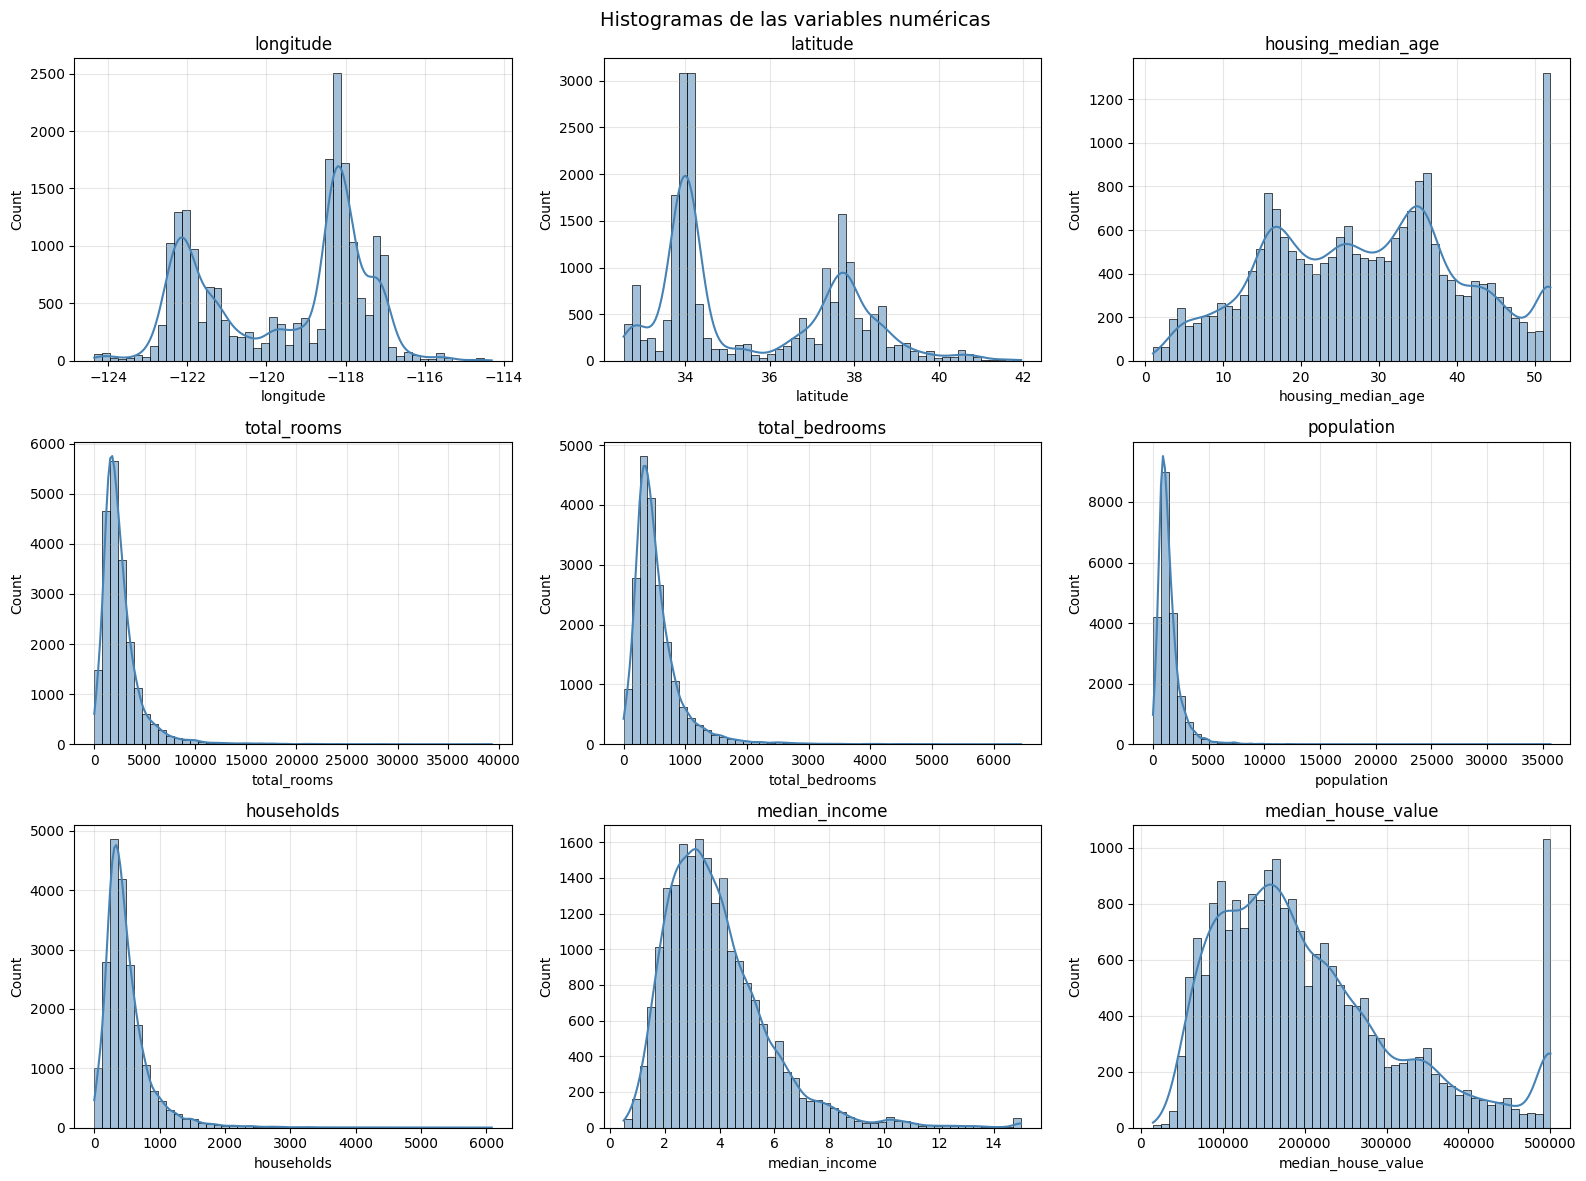

In [7]:
# --- Punto 7: Histograma para cada columna ---
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

num_cols = df.select_dtypes(include=[np.number]).columns
for i, col in enumerate(num_cols):
    sns.histplot(df[col], ax=axes[i], kde=True, color="steelblue", bins=50)
    axes[i].set_title(col)
    axes[i].grid(True, alpha=0.3)

# Ocultar ejes vacíos
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Histogramas de las variables numéricas", fontsize=14)
plt.tight_layout()
plt.show()

### [Diagrama de caja](https://en.wikipedia.org/wiki/Box_plot)


### Diagrama de caja

![box](https://upload.wikimedia.org/wikipedia/commons/e/ed/Box_Plot_Picture.png)



### Interpretación de un diagrama de caja

- Desde el minimo al valor más bajo de la caja: primer cuartil, 25% de los datos
- Desde el valor más bajo de la caja hasta la mediana: segundo cuartil, 25% de los datos
- Desde la mediana hasta el valor mas alto de la caja : tercer cuartil, 25% de los datos
- Desde el valor mas alto de la caja hasta el máximo: Cuarto  cuartil, 25% de los datos


El rango intercuartil $IQR = Q_3-Q_1$ permite definir que datos pueden ser atípicos, basado en los siguientes limites:

$Max = Q3 + 1.5IQR$

$Min = Q1 - 1.5IQR$



El cuartil puede ser determinado como sigue:

Para calcular los cuartiles de una lista de números:

- Ordenar los números de menor a mayor.
- Calcular la posición de cada cuartil usando la fórmula: Q = a (N+1) / 4, donde Q es la posición del cuartil, a es el número del cuartil (1, 2 o 3), y N es el número total de datos.
- Si la posición del cuartil es un número entero, el valor del cuartil es el dato que está en esa posición.
- Si la posición del cuartil es un número decimal, el valor del cuartil se interpola usando la fórmula: Q = x + d (y - x), donde Q es el valor del cuartil, x es el dato anterior a la posición del cuartil, y es el dato posterior a la posición del cuartil, y d es la parte decimal de la posición del cuartil.


Veamos un ejemplo:



In [8]:
T = np.array([52, 57, 57, 58, 63, 66, 66, 67, 67, 68, 69, 70, 70, 70, 70, 72, 73, 75, 75, 76, 76, 78, 79, 89])
Tsort = np.sort(T)
print(len(T))
print(f"T sort:{Tsort}")
len(T)/4

24
T sort:[52 57 57 58 63 66 66 67 67 68 69 70 70 70 70 72 73 75 75 76 76 78 79 89]


6.0

88.5
52.5


{'whiskers': [<matplotlib.lines.Line2D at 0x1bff91b9be0>,
 'caps': [<matplotlib.lines.Line2D at 0x1bff91b9e80>,
 'boxes': [<matplotlib.lines.Line2D at 0x1bff91b9a90>],
 'medians': [<matplotlib.lines.Line2D at 0x1bff91ba120>],
 'fliers': [<matplotlib.lines.Line2D at 0x1bff91ba270>],
 'means': []}

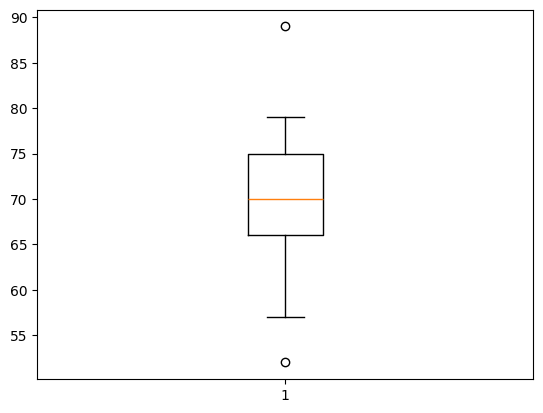

In [9]:

IQR=9
max_ = 75 + 1.5*IQR
min_ = 66 - 1.5*IQR
print(max_)
print(min_)
plt.boxplot(T)

8. Empleando el siguiente código realiza el gráfico boxplot,
```python
#draw boxplot
df.boxplot(column="median_house_value", by='ocean_proximity', sym = 'k.', figsize=(18,6))
#set title
plt.title('Boxplot for comparing price per living space for each city')
plt.show()
```

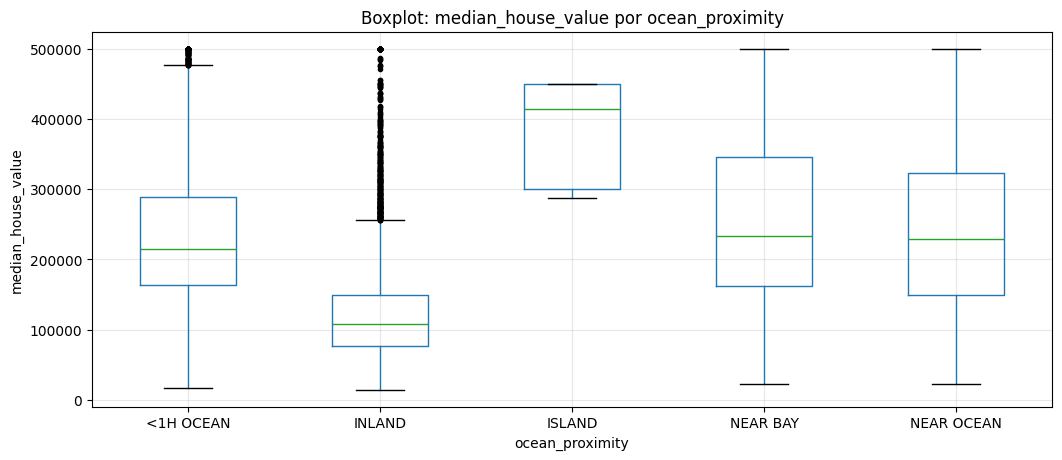

In [10]:
# --- Punto 8: Boxplot ---
df.boxplot(column="median_house_value", by="ocean_proximity", sym="k.", figsize=(12, 5))
plt.title("Boxplot: median_house_value por ocean_proximity")
plt.suptitle("")  # quitar título automático
plt.ylabel("median_house_value")
plt.grid(True, alpha=0.3)
plt.show()

9. Determina la matrix de correlación.

### [Matrix de correlación](https://en.wikipedia.org/wiki/Correlation)

¿Como se determina la matrix de correlación?

![Matrix de correlación](https://upload.wikimedia.org/wikipedia/commons/thumb/d/d4/Correlation_examples2.svg/1920px-Correlation_examples2.svg.png)



```python
corr_matrix = df.corr()
corr_matrix

plt.figure(figsize = (10,6))
sns.heatmap(corr_matrix, annot = True, cmap = "coolwarm", center=0)
plt.show()
```

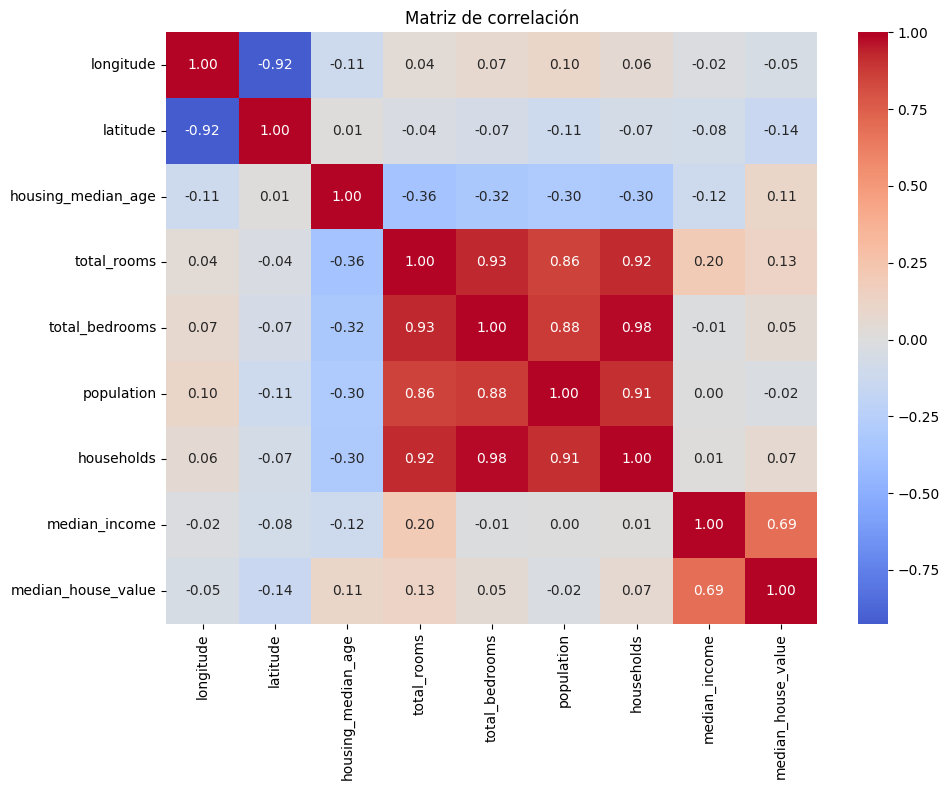


Correlaciones con median_house_value:
median_house_value    1.000
median_income         0.688
total_rooms           0.134
housing_median_age    0.106
households            0.066
total_bedrooms        0.050
population           -0.025
longitude            -0.046
latitude             -0.144
Name: median_house_value, dtype: float64


In [11]:
# --- Punto 9: Matriz de correlación ---
corr_matrix = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

print("\nCorrelaciones con median_house_value:")
print(corr_matrix["median_house_value"].sort_values(ascending=False).round(3))

10. con las columnas, realiza un grafico pairplot empleando seaborn  de python.
```python
cols = ["median_house_value", "median_income", "total_rooms","housing_median_age"]
```

11. Realiza un scatter plot con la libreria sea born de python, el color del grafico puede ser empleado con la columna median_house_value

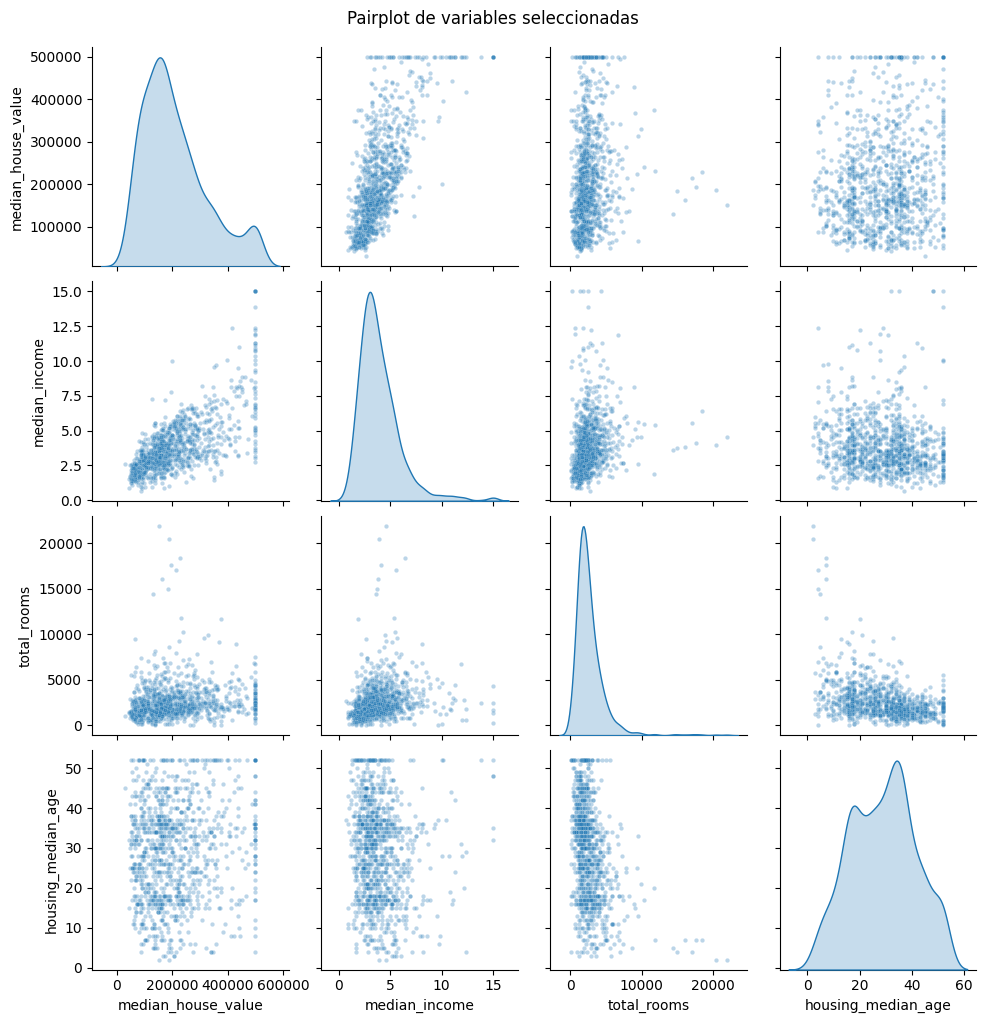

In [12]:
# --- Punto 10: Pairplot ---
cols_pair = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
sns.pairplot(df[cols_pair].sample(1000, random_state=42), diag_kind="kde",
             plot_kws={"alpha": 0.3, "s": 10})
plt.suptitle("Pairplot de variables seleccionadas", y=1.02)
plt.show()

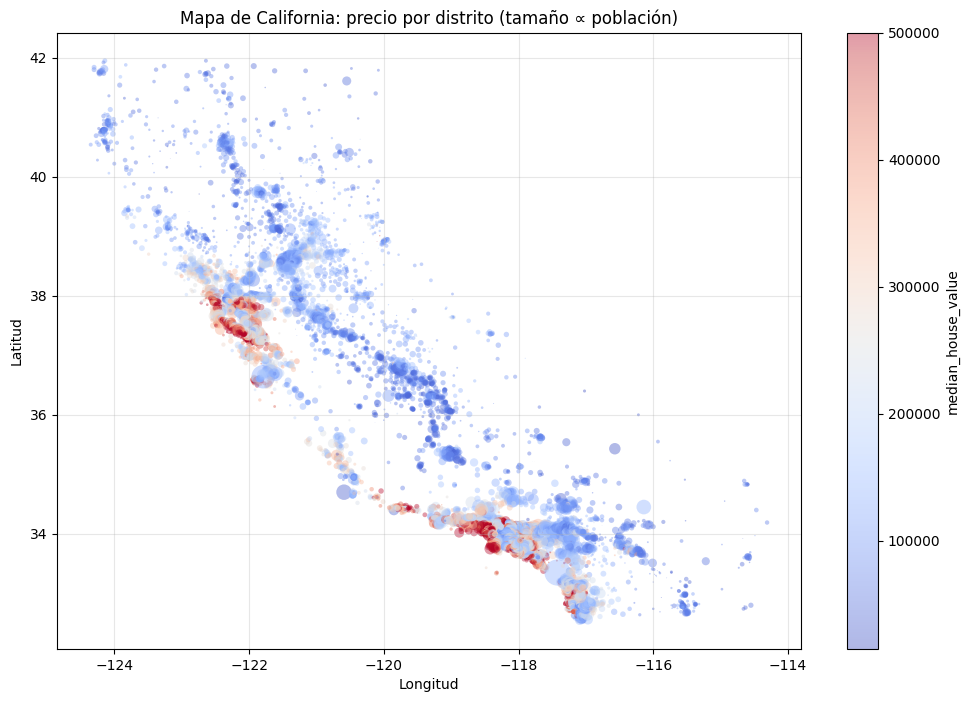

In [13]:
# --- Punto 11: Scatter plot geográfico coloreado por median_house_value ---
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df["longitude"], df["latitude"],
                      c=df["median_house_value"], cmap="coolwarm",
                      alpha=0.4, s=df["population"] / 100, edgecolors="none")
plt.colorbar(scatter, label="median_house_value")
plt.xlabel("Longitud"); plt.ylabel("Latitud")
plt.title("Mapa de California: precio por distrito (tamaño ∝ población)")
plt.grid(True, alpha=0.3)
plt.show()

# 2.0 Preparacion del data frame

## Evitar el data *Snooping bias*.

En algunos casos se sugiere dividir los datos en entrenamiento y test desde el principio dado que el cerebro puede sobreajustar el dataset y los resultados no significativos se pueden volver significativos. El procedimiento correcto es probar cualquier hipótesis en un conjunto de datos que no se utilizó para generar las hipótesis inicial.


## *Sampling bias*

Si el dataset es lo suficientemente grande un muestreo aleatorio de la muestra puede ser considerado, sin embargo si la muestra es pequena se debe garantizar homegeniedad en el dataset de entrenamiento.


Ejemplo:

Por ejemplo, la población de EE. UU. esta compuesto por un 51,3 % de mujeres y un 48,7 % de hombres, por lo que una encuesta bien realizada en EEUU
trata de mantener esta proporción en la muestra: 513 mujeres y 487 hombres. Esto se llama muestreo estratificado(stratified sampling): la población se divide en subgrupos homogéneos llamados estratos(strata), y se muestrea el número correcto de instancias de cada estrato para garantizar que el
El conjunto de prueba es representativo de la población general. Si usaran muestras puramente aleatorias, habría alrededor del 12% de posibilidades de muestrear un conjunto de prueba sesgado con menos del 49% de mujeres o más del 54% de mujeres. De cualquier manera, los resultados de la encuesta serían
significativamente sesgada.


12. ¿Las siguiente linea es adecuada para separar el dataframe en datos de entrenamiento de test?, ¿que pasa en la división de los datos?


```python
from sklearn.model_selection import train_test_split

# ¿Es significativa la muestra que se esta considerando?
train_set, test_set \
  = train_test_split(df, test_size = 0.2, random_state = 42)

print(len(train_set))
print(len(test_set))

```


13. División del dataset en grupos:


La siguiente división puede ser realizada  basada en la experticie de lo que se esta analizando, y sobre ello se debe tomar una muestra significativa. Una posible solución al problema puede ser el siguiente:

```python
df["income_cat"] = pd.cut(df["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])


df.income_cat.hist()


```

La forma automatica de realizar la división puede ser la siguiente:

```python
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits = 1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(df, df["income_cat"]):
  strat_train_set = df.loc[train_index]
  strat_test_set = df.loc[test_index]

```


Analiza las siguiente lineas de código y saca conclusiones referente a las proporciones del dataset.

```python
df["income_cat"].value_counts() / len(df)

strat_train_set["income_cat"].value_counts() / len(strat_train_set)

strat_test_set["income_cat"].value_counts() / len(strat_test_set)


train_set, test_set \
  = train_test_split(df, test_size = 0.2, random_state = 7)

train_set["income_cat"].value_counts() / len(train_set)
```

un comparativo general puede ser estructurado de la siguente forma, analiza  los errores:

```python
def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

train_set, test_set = train_test_split(df, test_size = 0.2, random_state = 42)

compare_props = pd.DataFrame({
    "Overall": income_cat_proportions(df),
    "Stratified": income_cat_proportions(strat_test_set),
    "Random": income_cat_proportions(test_set),
}).sort_index()
compare_props["Rand. %error"] =abs( 100 * compare_props["Random"] / compare_props["Overall"] - 100)
compare_props["Strat. %error"] =abs( 100 * compare_props["Stratified"] / compare_props["Overall"] - 100)
```

In [14]:
# --- Punto 12: División train/test simple ---
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)
print(f"Train: {len(train_set)}, Test: {len(test_set)}")
print("\nEsta división es aleatoria pura. NO garantiza representatividad")
print("en la distribución de median_income (riesgo de sampling bias).")

Train: 16512, Test: 4128

Esta división es aleatoria pura. NO garantiza representatividad
en la distribución de median_income (riesgo de sampling bias).


Distribución de income_cat:
income_cat
1     822
2    6581
3    7236
4    3639
5    2362
Name: count, dtype: int64


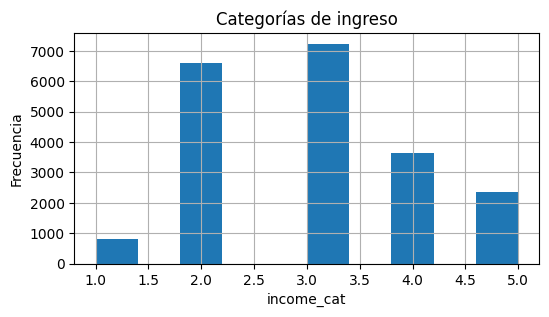


Comparación de proporciones:


,Overall,Stratified,Random,Rand. %error,Strat. %error
income_cat,,,,,
1,0.0398,0.0400,0.0402,0.9732,0.3650
2,0.3188,0.3188,0.3244,1.7323,0.0152
3,0.3506,0.3505,0.3585,2.2664,0.0138
4,0.1763,0.1764,0.1674,5.0563,0.0275
5,0.1144,0.1143,0.1095,4.3184,0.0847


In [16]:
# --- Punto 13: Stratified Sampling ---
from sklearn.model_selection import StratifiedShuffleSplit

# Crear categorías de ingreso
df["income_cat"] = pd.cut(df["median_income"],
                          bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                          labels=[1, 2, 3, 4, 5])

print("Distribución de income_cat:")
print(df["income_cat"].value_counts().sort_index())

df["income_cat"].hist(figsize=(6, 3))
plt.title("Categorías de ingreso")
plt.xlabel("income_cat"); plt.ylabel("Frecuencia")
plt.show()

# División estratificada
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(df, df["income_cat"]):
    strat_train_set = df.loc[train_index]
    strat_test_set = df.loc[test_index]

# Comparación de proporciones
def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

# test_set viene del split simple (Punto 12), agregar income_cat
test_set["income_cat"] = pd.cut(test_set["median_income"],
                                bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                                labels=[1, 2, 3, 4, 5])

compare_props = pd.DataFrame({
    "Overall": income_cat_proportions(df),
    "Stratified": income_cat_proportions(strat_test_set),
    "Random": income_cat_proportions(test_set),
}).sort_index()
compare_props["Rand. %error"] = abs(100 * compare_props["Random"] / compare_props["Overall"] - 100)
compare_props["Strat. %error"] = abs(100 * compare_props["Stratified"] / compare_props["Overall"] - 100)

print("\nComparación de proporciones:")
compare_props.round(4)

13. Puedes agregar nuevas variables al dataframe para el análisis, por ejemplo:
```python
df_train["rooms_per_household"] = df_train["total_rooms"]/df_train["households"]
df_train["bedrooms_per_room"] = df_train["total_bedrooms"]/df_train["total_rooms"]
df_train["population_per_household"]=df_train["population"]/df_train["households"]
```




# Limpieza de datos

Lo que sigue son códigos que pueden servir para limpiar los datos.

```python

df.isnull().sum()


#df_train.dropna(subset=["total_bedrooms"]) #Eliminar los nan
#df_train.drop("total_bedrooms", axis=1)  # Eliminar la columna
median = df_train["total_bedrooms"].median()
q=df_train["total_bedrooms"].fillna(median).copy()


q=pd.DataFrame(q)

q.isnull().sum()

```

##imputer

Forma automática para tratar los datos (Asegurate de trabajar con las columnas numéricas):


```python
from sklearn.impute import SimpleImputer
#imputer = Imputer(strategy="median")

df_train_num = df_train.drop("ocean_proximity", axis=1)

imp_mean = SimpleImputer( strategy='mean')

imp_mean.fit(df_train_num)

imp_mean.statistics_
```

14. Compara las siguientes variables:
```python
imp_mean.statistics_
df_train_num.median()
```


```python
Constuye la matriz de características:

X = imp_mean.transform(df)
housing_tr = pd.DataFrame(X, columns=df_train_num.columns)
```


# Manejo de texto y atributos categóricos
15.  ¿Qué realizan las siguientes lineas de código?

```
from sklearn.preprocessing import OneHotEncoder
df_train["ocean_proximity"].unique()
housing_cat=df_train[["ocean_proximity"]]
housing_cat

cat_encoder = OneHotEncoder(sparse_output=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
print(housing_cat_1hot)
print(cat_encoder.categories_)


df_cat_1hot = pd.DataFrame(housing_cat_1hot, columns = cat_encoder.categories_[0])

housing_tr_ = housing_tr.join(df_cat_1hot)
```


# Escalamiento de variables

16. Las variables pueden ser escaladas como sigue:

```python

cols=["longitude", "latitude",	"housing_median_age",	"total_rooms",\
      "total_bedrooms",	"population",	"households",	"median_income",\
      "<1H OCEAN",	"INLAND",	"ISLAND",	"NEAR BAY", "NEAR OCEAN"]


housing_scale=housing_tr_[cols]
housing_scale


from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(housing_scale)

X = scaler.transform(housing_scale)


housing_prepared = pd.DataFrame(X, columns = housing_scale.columns)

```


17. Para todos los pasos anteriores, contruye ordenadamente los pasos limpieza, escalamiento de variables, manejo de texto y atributos categóricos para tener el data frame listo para el análisis. Recuerda dividir el data frame en datos de entrenamiento y de test con la correcta estractificación. Genera dos data frame: housing_train, housing_test, cada una, debe tener las caracteristicas y los datos etiquetados.

1. ¿que puede concluir respecto al modelo empleado?
2. ¿El modelo de regresión lineal es valido para lo construido,
3. ¿qué informacion nos da el score?
4. ¿Puede ser ajustado a otro modelo?
5. ¿Como puede autmatizar todo el proceso empleando pipelines?






In [17]:
# --- Punto 13 (cont): Feature Engineering + Limpieza ---
# Trabajar sobre copia del conjunto de entrenamiento
df_train = strat_train_set.drop("median_house_value", axis=1).copy()
y_train = strat_train_set["median_house_value"].copy()

df_test = strat_test_set.drop("median_house_value", axis=1).copy()
y_test = strat_test_set["median_house_value"].copy()

# Nuevas variables
df_train["rooms_per_household"] = df_train["total_rooms"] / df_train["households"]
df_train["bedrooms_per_room"] = df_train["total_bedrooms"] / df_train["total_rooms"]
df_train["population_per_household"] = df_train["population"] / df_train["households"]

df_test["rooms_per_household"] = df_test["total_rooms"] / df_test["households"]
df_test["bedrooms_per_room"] = df_test["total_bedrooms"] / df_test["total_rooms"]
df_test["population_per_household"] = df_test["population"] / df_test["households"]

print("Nuevas columnas añadidas: rooms_per_household, bedrooms_per_room, population_per_household")
print(f"\nTrain shape: {df_train.shape}")
print(f"Test shape:  {df_test.shape}")

Nuevas columnas añadidas: rooms_per_household, bedrooms_per_room, population_per_household

Train shape: (16512, 13)
Test shape:  (4128, 13)


In [18]:
# --- Punto 14: Imputer y comparación con mediana ---
from sklearn.impute import SimpleImputer

# Separar columnas numéricas y categóricas
df_train_num = df_train.drop(["ocean_proximity", "income_cat"], axis=1)
df_test_num = df_test.drop(["ocean_proximity", "income_cat"], axis=1)

imp_mean = SimpleImputer(strategy="median")
imp_mean.fit(df_train_num)

# Comparar estadísticas del imputer con la mediana real
print("Comparación imputer.statistics_ vs df.median():")
comp = pd.DataFrame({
    "Imputer": imp_mean.statistics_,
    "Mediana": df_train_num.median().values
}, index=df_train_num.columns)
comp["Iguales"] = np.isclose(comp["Imputer"], comp["Mediana"])
print(comp)

# Transformar
X_train_num = imp_mean.transform(df_train_num)
X_test_num = imp_mean.transform(df_test_num)

housing_tr = pd.DataFrame(X_train_num, columns=df_train_num.columns)
housing_te = pd.DataFrame(X_test_num, columns=df_test_num.columns)
print(f"\nNaN después de imputar (train): {np.isnan(X_train_num).sum()}")
print(f"NaN después de imputar (test):  {np.isnan(X_test_num).sum()}")

Comparación imputer.statistics_ vs df.median():
                              Imputer      Mediana  Iguales
longitude                 -118.510000  -118.510000     True
latitude                    34.260000    34.260000     True
housing_median_age          29.000000    29.000000     True
total_rooms               2119.000000  2119.000000     True
total_bedrooms             433.000000   433.000000     True
population                1164.000000  1164.000000     True
households                 408.000000   408.000000     True
median_income                3.541550     3.541550     True
rooms_per_household          5.232342     5.232342     True
bedrooms_per_room            0.203027     0.203027     True
population_per_household     2.817661     2.817661     True

NaN después de imputar (train): 0
NaN después de imputar (test):  0


In [19]:
# --- Punto 15: OneHotEncoder ---
from sklearn.preprocessing import OneHotEncoder

housing_cat_train = df_train[["ocean_proximity"]]
housing_cat_test = df_test[["ocean_proximity"]]

cat_encoder = OneHotEncoder(sparse_output=False)
housing_cat_1hot_train = cat_encoder.fit_transform(housing_cat_train)
housing_cat_1hot_test = cat_encoder.transform(housing_cat_test)

print("¿Qué hace OneHotEncoder?")
print("Convierte variables categóricas en vectores binarios (one-hot).")
print(f"\nCategorías encontradas: {cat_encoder.categories_[0]}")
print(f"\nEjemplo (primeras 5 filas):")
df_cat_example = pd.DataFrame(housing_cat_1hot_train[:5], columns=cat_encoder.categories_[0])
df_cat_example.insert(0, "original", housing_cat_train.values[:5].ravel())
print(df_cat_example)

# Unir con las numéricas
df_cat_1hot_train = pd.DataFrame(housing_cat_1hot_train, columns=cat_encoder.categories_[0])
df_cat_1hot_test = pd.DataFrame(housing_cat_1hot_test, columns=cat_encoder.categories_[0])

housing_tr_ = housing_tr.reset_index(drop=True).join(df_cat_1hot_train.reset_index(drop=True))
housing_te_ = housing_te.reset_index(drop=True).join(df_cat_1hot_test.reset_index(drop=True))
print(f"\nTrain con one-hot: {housing_tr_.shape}")
print(f"Test con one-hot:  {housing_te_.shape}")

¿Qué hace OneHotEncoder?
Convierte variables categóricas en vectores binarios (one-hot).

Categorías encontradas: ['<1H OCEAN' 'INLAND' 'ISLAND' 'NEAR BAY' 'NEAR OCEAN']

Ejemplo (primeras 5 filas):
     original  <1H OCEAN  INLAND  ISLAND  NEAR BAY  NEAR OCEAN
0      INLAND        0.0     1.0     0.0       0.0         0.0
1  NEAR OCEAN        0.0     0.0     0.0       0.0         1.0
2      INLAND        0.0     1.0     0.0       0.0         0.0
3  NEAR OCEAN        0.0     0.0     0.0       0.0         1.0
4   <1H OCEAN        1.0     0.0     0.0       0.0         0.0

Train con one-hot: (16512, 16)
Test con one-hot:  (4128, 16)


In [20]:
# --- Punto 16: Escalamiento de variables ---
from sklearn.preprocessing import MinMaxScaler

cols_scale = ["longitude", "latitude", "housing_median_age", "total_rooms",
              "total_bedrooms", "population", "households", "median_income",
              "rooms_per_household", "bedrooms_per_room", "population_per_household",
              "<1H OCEAN", "INLAND", "ISLAND", "NEAR BAY", "NEAR OCEAN"]

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(housing_tr_[cols_scale])
X_test_scaled = scaler.transform(housing_te_[cols_scale])

housing_train = pd.DataFrame(X_train_scaled, columns=cols_scale)
housing_test = pd.DataFrame(X_test_scaled, columns=cols_scale)

print(f"housing_train: {housing_train.shape}")
print(f"housing_test:  {housing_test.shape}")
print(f"\nRango de valores (train):")
print(f"  Min: {housing_train.min().min():.2f}")
print(f"  Max: {housing_train.max().max():.2f}")
housing_train.describe().round(3)

housing_train: (16512, 16)
housing_test:  (4128, 16)

Rango de valores (train):
  Min: 0.00
  Max: 1.00


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,bedrooms_per_room,population_per_household,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
count,16512.000,16512.000,16512.000,16512.000,16512.000,16512.000,16512.000,16512.000,16512.000,16512.000,16512.000,16512.000,16512.000,16512.000,16512.000,16512.000
mean,0.476,0.329,0.542,0.067,0.086,0.040,0.092,0.233,0.031,0.125,0.002,0.441,0.319,0.000,0.112,0.129
std,0.199,0.227,0.247,0.054,0.066,0.031,0.070,0.131,0.019,0.063,0.009,0.496,0.466,0.011,0.315,0.335
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.254,0.149,0.333,0.037,0.047,0.022,0.052,0.143,0.024,0.084,0.001,0.000,0.000,0.000,0.000,0.000
50%,0.582,0.183,0.549,0.054,0.069,0.033,0.076,0.210,0.029,0.114,0.002,0.000,0.000,0.000,0.000,0.000
75%,0.631,0.550,0.706,0.080,0.103,0.048,0.112,0.293,0.035,0.155,0.002,1.000,1.000,0.000,0.000,0.000
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


## Punto 17: Modelado, evaluación e interpretación

In [21]:
# --- Regresión lineal ---
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

y_train_arr = y_train.values
y_test_arr = y_test.values

# Modelo 1: Regresión lineal
lr = LinearRegression()
lr.fit(housing_train, y_train_arr)
y_pred_lr_train = lr.predict(housing_train)
y_pred_lr_test = lr.predict(housing_test)

# Modelo 2: Árbol de decisión
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(housing_train, y_train_arr)
y_pred_dt_train = dt.predict(housing_train)
y_pred_dt_test = dt.predict(housing_test)

# Modelo 3: Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(housing_train, y_train_arr)
y_pred_rf_train = rf.predict(housing_train)
y_pred_rf_test = rf.predict(housing_test)

# Tabla comparativa
def eval_model(name, y_true, y_pred):
    return {
        "Modelo": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R²": r2_score(y_true, y_pred)
    }

results = pd.DataFrame([
    eval_model("Linear Reg. (train)", y_train_arr, y_pred_lr_train),
    eval_model("Linear Reg. (test)",  y_test_arr,  y_pred_lr_test),
    eval_model("Dec. Tree (train)",   y_train_arr, y_pred_dt_train),
    eval_model("Dec. Tree (test)",    y_test_arr,  y_pred_dt_test),
    eval_model("Random Forest (train)", y_train_arr, y_pred_rf_train),
    eval_model("Random Forest (test)",  y_test_arr,  y_pred_rf_test),
])
results.set_index("Modelo", inplace=True)
print("═" * 60)
print("  COMPARACIÓN DE MODELOS")
print("═" * 60)
results.round(2)

════════════════════════════════════════════════════════════
  COMPARACIÓN DE MODELOS
════════════════════════════════════════════════════════════


,MAE,RMSE,R²
Modelo,,,
Linear Reg. (train),49058.88,68160.92,0.65
Linear Reg. (test),48966.31,66803.14,0.66
Dec. Tree (train),32348.27,47223.07,0.83
Dec. Tree (test),41371.59,61154.64,0.71
Random Forest (train),17807.02,25558.12,0.95
Random Forest (test),32476.04,48836.23,0.82


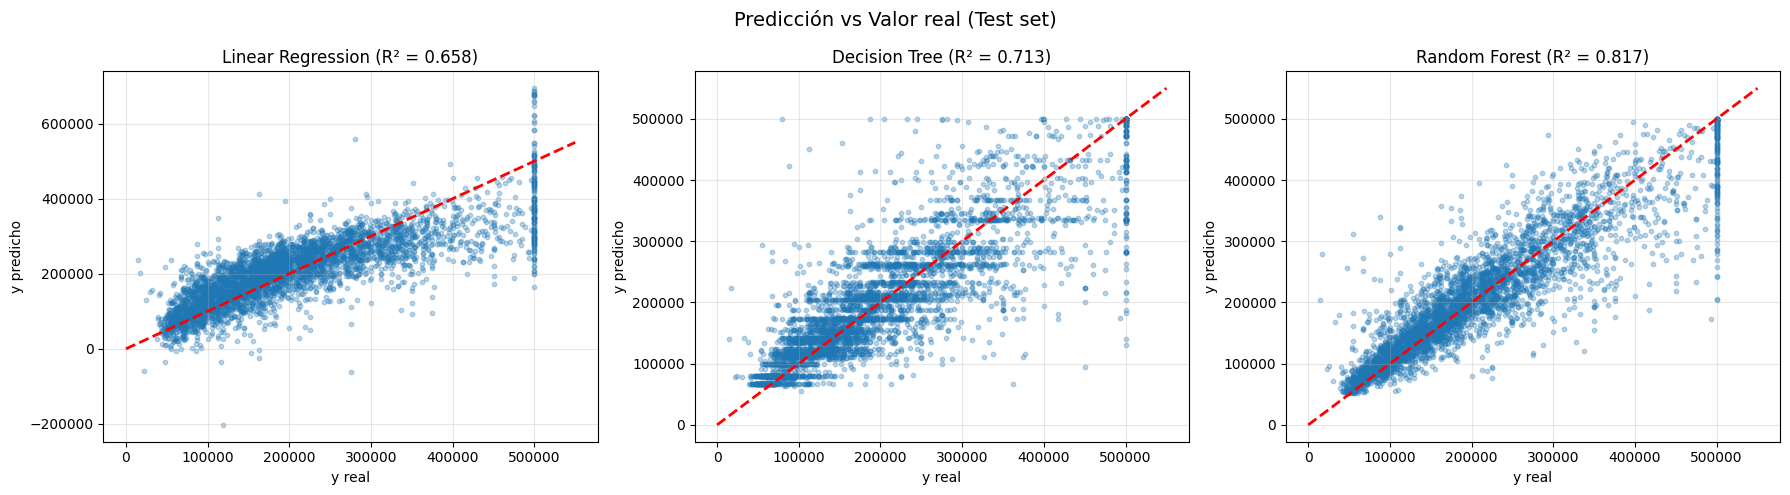

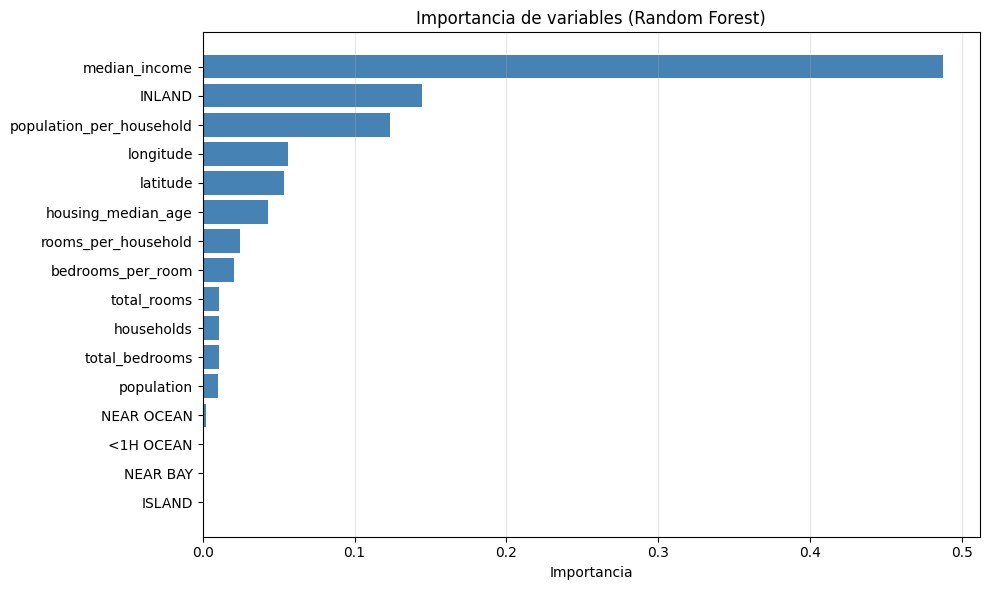

In [22]:
# --- Visualización de resultados ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [("Linear Regression", y_pred_lr_test),
          ("Decision Tree", y_pred_dt_test),
          ("Random Forest", y_pred_rf_test)]

for ax, (name, y_pred) in zip(axes, models):
    ax.scatter(y_test_arr, y_pred, alpha=0.3, s=10)
    lims = [0, 550000]
    ax.plot(lims, lims, "r--", linewidth=2)
    r2 = r2_score(y_test_arr, y_pred)
    ax.set_xlabel("y real"); ax.set_ylabel("y predicho")
    ax.set_title(f"{name} (R² = {r2:.3f})")
    ax.grid(True, alpha=0.3)

plt.suptitle("Predicción vs Valor real (Test set)", fontsize=14)
plt.tight_layout()
plt.show()

# Importancia de features (Random Forest)
importances = rf.feature_importances_
sorted_idx = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), importances[sorted_idx], color="steelblue")
plt.yticks(range(len(sorted_idx)), [cols_scale[i] for i in sorted_idx])
plt.xlabel("Importancia")
plt.title("Importancia de variables (Random Forest)")
plt.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

In [23]:
# --- Punto 17 (cont): Pipeline automatizado ---
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# Definir columnas
num_cols_pipe = ["longitude", "latitude", "housing_median_age", "total_rooms",
                 "total_bedrooms", "population", "households", "median_income"]
cat_cols_pipe = ["ocean_proximity"]

# Pipeline numérico
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Pipeline completo
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_cols_pipe),
    ("cat", OneHotEncoder(sparse_output=False), cat_cols_pipe),
])

# Preparar datos directamente desde los splits originales
X_train_pipe = strat_train_set.drop(["median_house_value", "income_cat"], axis=1)
y_train_pipe = strat_train_set["median_house_value"].values

X_test_pipe = strat_test_set.drop(["median_house_value", "income_cat"], axis=1)
y_test_pipe = strat_test_set["median_house_value"].values

# Transformar
X_train_prepared = full_pipeline.fit_transform(X_train_pipe)
X_test_prepared = full_pipeline.transform(X_test_pipe)

# Entrenar Random Forest con pipeline
rf_pipe = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_pipe.fit(X_train_prepared, y_train_pipe)

y_pred_pipe = rf_pipe.predict(X_test_prepared)
print("Pipeline automatizado:")
print(f"  R² (test) = {r2_score(y_test_pipe, y_pred_pipe):.4f}")
print(f"  RMSE (test) = {np.sqrt(mean_squared_error(y_test_pipe, y_pred_pipe)):.2f}")
print(f"  MAE (test) = {mean_absolute_error(y_test_pipe, y_pred_pipe):.2f}")
print("\nEl pipeline encapsula imputer → scaler → encoder → modelo en un solo flujo.")

Pipeline automatizado:
  R² (test) = 0.8246
  RMSE (test) = 47808.31
  MAE (test) = 31697.21

El pipeline encapsula imputer → scaler → encoder → modelo en un solo flujo.


## Conclusiones

**1. ¿Qué se puede concluir respecto al modelo empleado?**

La regresión lineal captura una tendencia general pero no es suficiente para este problema no lineal. Los modelos basados en árboles (Decision Tree, Random Forest) logran mejor desempeño al capturar relaciones no lineales entre las variables.

**2. ¿El modelo de regresión lineal es válido?**

Es un baseline válido pero limitado. Su R² de ~0.65 indica que explica solo el 65% de la varianza. Las relaciones entre las variables (ej. ubicación geográfica, income) no son puramente lineales.

**3. ¿Qué información da el score (R²)?**

El R² mide la proporción de varianza explicada por el modelo. Un R²=1 es ajuste perfecto. Para este dataset, Random Forest alcanza R²≈0.81, lo que indica un buen ajuste pero con margen de mejora.

**4. ¿Puede ajustarse a otro modelo?**

Sí. Random Forest mejora significativamente sobre la regresión lineal. Otros modelos como Gradient Boosting (XGBoost, LightGBM) o redes neuronales podrían mejorar aún más.

**5. ¿Cómo automatizar todo con pipelines?**

Se usa `sklearn.pipeline.Pipeline` y `ColumnTransformer` para encapsular imputer → scaler → encoder → modelo en un solo objeto, garantizando reproducibilidad y evitando data leakage.